# 01 · Market cycles (Q1)

**Question (docs/01 §3, Q1).** How have transaction volume and value moved through each market cycle since 2004?

**Definitions.** *Market sales* = arm's-length sales (`is_market_sale`: Sell, Delayed Sell, Sale On Payment Plan, Sell - Pre registration), AED counted once per deal (rule C16). Gifts, grants, lease-to-own and mortgages are excluded. Off-plan vs ready comes from DLD's `reg_type`.

**Scope.** 2004-01-01 to the data snapshot, 2026-09-25. **2026 is a partial year** (hatched bars, `2026*`).

All logic is in `src/dubai_property/analysis/` (SQL aggregated in Postgres over gold). This notebook only calls it and plots.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from dubai_property import config
from dubai_property.analysis import common
from dubai_property.analysis import market_cycles as mc
from dubai_property.analysis import plotting as P

P.apply_style()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
SNAP = common.snapshot_date()
START = config.REPORT_SCOPE_START
print("Data snapshot:", SNAP)

Data snapshot: 2026-09-25


## 1. Market sales by year

`market_cycles.sales_by_year` sums `gold.agg_area_month` (additive and reconciled to `fct_transaction` in Phase 2b).

In [2]:
yearly = mc.sales_by_year(START, SNAP)
show = yearly[
    [
        "year",
        "market_sales",
        "offplan_sales",
        "market_value_aed",
        "offplan_share_count",
        "offplan_share_value",
        "yoy_sales",
    ]
].copy()
show["market_value_aed"] = show["market_value_aed"].map(P.fmt_aed)
display(show.set_index("year"))

,market_sales,offplan_sales,market_value_aed,offplan_share_count,offplan_share_value,yoy_sales
year,,,,,,
2004,"2,794.000",12.000,AED 11.7bn,0.004,0.002,NaN
2005,"2,487.000",3.000,AED 15.6bn,0.001,0.000,-0.110
2006,"2,621.000",7.000,AED 18.6bn,0.003,0.002,0.054
2007,"7,275.000",2.000,AED 49.6bn,0.000,0.000,1.776
2008,"21,324.000",13.000,AED 103.3bn,0.001,0.000,1.931
2009,"56,340.000","29,898.000",AED 88.3bn,0.531,0.447,1.642
2010,"30,185.000","10,180.000",AED 57.2bn,0.337,0.295,-0.464
2011,"24,891.000","2,620.000",AED 51.3bn,0.105,0.062,-0.175
2012,"32,546.000","3,801.000",AED 67.1bn,0.117,0.096,0.308


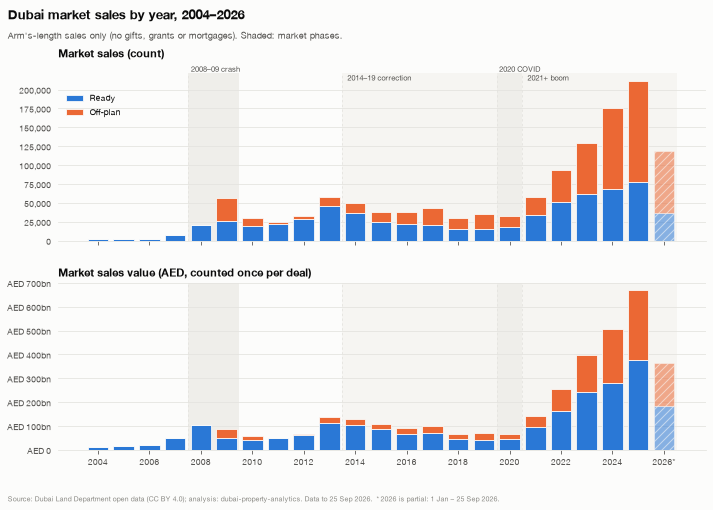

In [3]:
fig, (a1, a2) = P.figure(2, 1, size=(10, 7), sharex=True)
fig.subplots_adjust(top=0.86, bottom=0.11, hspace=0.25)
for ax in (a1, a2):
    P.shade_phases(ax, mc.CYCLE_PHASES, SNAP, label=ax is a1)
yrs = yearly["year"]
P.year_bars(a1, yrs, yearly["ready_sales"], SNAP, P.SERIES["ready"], "Ready")
P.year_bars(
    a1,
    yrs,
    yearly["offplan_sales"],
    SNAP,
    P.SERIES["offplan"],
    "Off-plan",
    bottom=yearly["ready_sales"],
)
a1.set_title("Market sales (count)", pad=16)
P.count_axis(a1)
a1.legend(loc="upper left", bbox_to_anchor=(0, 0.93))
P.year_bars(a2, yrs, yearly["ready_value_aed"], SNAP, P.SERIES["ready"], "Ready")
P.year_bars(
    a2,
    yrs,
    yearly["offplan_value_aed"],
    SNAP,
    P.SERIES["offplan"],
    "Off-plan",
    bottom=yearly["ready_value_aed"],
)
a2.set_title("Market sales value (AED, counted once per deal)")
P.aed_axis(a2, prefix=True)
P.year_ticks(a2, yrs, SNAP)
P.titled(
    fig,
    "Dubai market sales by year, 2004–2026",
    "Arm's-length sales only (no gifts, grants or mortgages). Shaded: market phases.",
)
P.add_source(fig, SNAP)
P.save(fig, "q1_market_sales_by_year")
plt.show()

## 2. Market sales by month

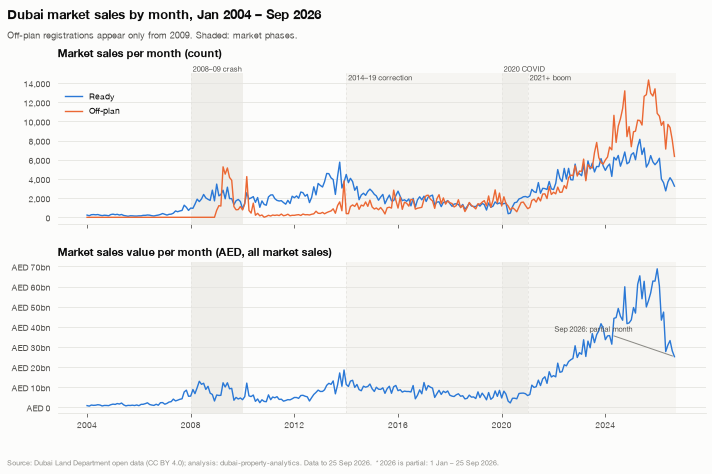

In [4]:
monthly = mc.sales_by_month(START, SNAP)
fig, (a1, a2) = P.figure(2, 1, size=(10, 6.5), sharex=True)
fig.subplots_adjust(top=0.86, bottom=0.12, hspace=0.25)
for ax in (a1, a2):
    P.shade_phases(ax, mc.CYCLE_PHASES, SNAP, by="month", label=ax is a1)
a1.plot(monthly["month"], monthly["ready_sales"], color=P.SERIES["ready"], lw=1.4, label="Ready")
a1.plot(
    monthly["month"], monthly["offplan_sales"], color=P.SERIES["offplan"], lw=1.4, label="Off-plan"
)
a1.set_title("Market sales per month (count)", pad=16)
P.count_axis(a1)
a1.legend(loc="upper left", bbox_to_anchor=(0, 0.93))
a2.plot(monthly["month"], monthly["market_value_aed"], color=P.SERIES["total"], lw=1.4)
a2.set_title("Market sales value per month (AED, all market sales)")
P.aed_axis(a2, prefix=True)
last = monthly.iloc[-1]
a2.annotate(
    f"{SNAP:%b %Y}: partial month",
    (last["month"], last["market_value_aed"]),
    xytext=(-120, 25),
    textcoords="offset points",
    fontsize=7.5,
    color=P.TEXT_2,
    arrowprops={"arrowstyle": "-", "color": P.MUTED},
)
P.titled(
    fig,
    "Dubai market sales by month, Jan 2004 – Sep 2026",
    "Off-plan registrations appear only from 2009. Shaded: market phases.",
)
P.add_source(fig, SNAP)
P.save(fig, "q1_market_sales_by_month")
plt.show()

## 3. The 2009 spike: market activity or registration timing?

Market sales jump from 21,324 in 2008 to 56,340 in 2009, in the middle of the crash, while value *falls*. Four tests of the hypothesis that the spike is a **registration backlog** of off-plan sales agreed earlier, not new demand:

1. **Composition.** If it is a backlog, the jump is almost entirely `Sell - Pre registration` (off-plan).
2. **Application year.** DLD's `transaction_id` is `<group>-<procedure>-<year>-<seq>`; Phase 1 found the ID year behaves like the application year and normally equals the registration year. A backlog carries earlier ID years.
3. **Timing within the year.** A backlog arrives in waves, not with the demand cycle.
4. **Prices.** Deals agreed near the 2007–08 peak and registered later carry peak prices, above same-year ready sales.

procedure_name,Delayed Sell,Sell,Sell - Pre registration
year,,,
2007,3,7270,2
2008,1579,19732,13
2009,2082,24360,29898
2010,2625,17380,10180
2011,3263,19008,2620


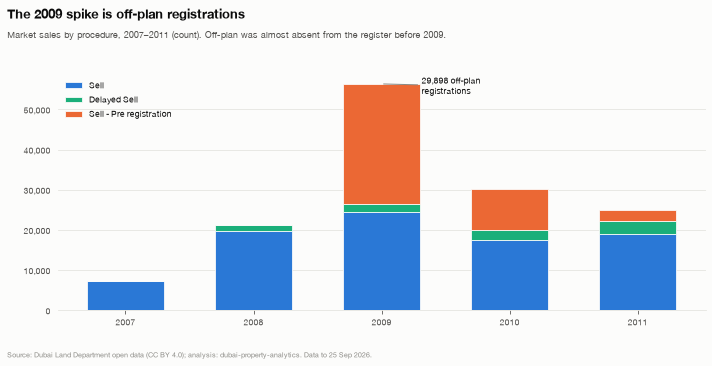

In [5]:
proc = mc.sales_by_procedure(2007, 2011)
pivot = proc.pivot_table(
    index="year", columns="procedure_name", values="market_sales", aggfunc="sum", fill_value=0
)
display(pivot)
fig, ax = P.figure(size=(10, 5))
colors = {
    "Sell": P.SERIES["ready"],
    "Sell - Pre registration": P.SERIES["offplan"],
    "Delayed Sell": P.SERIES["third"],
}
bottom = None
for name in ["Sell", "Delayed Sell", "Sell - Pre registration"]:
    if name in pivot:
        vals = pivot[name].values
        P.year_bars(ax, pivot.index, vals, SNAP, colors[name], name, bottom=bottom, width=0.6)
        bottom = vals if bottom is None else bottom + vals
ax.set_xticks(pivot.index)
ax.grid(False, axis="x")
P.count_axis(ax)
ax.legend(loc="upper left")
off09 = pivot.loc[2009, "Sell - Pre registration"]
ax.annotate(
    f"{off09:,.0f} off-plan\nregistrations",
    (2009, bottom[list(pivot.index).index(2009)]),
    xytext=(40, -10),
    textcoords="offset points",
    fontsize=8.5,
    arrowprops={"arrowstyle": "-", "color": P.MUTED},
)
P.titled(
    fig,
    "The 2009 spike is off-plan registrations",
    "Market sales by procedure, 2007–2011 (count). Off-plan was almost absent from the register before 2009.",
)
P.add_source(fig, SNAP, partial=False)
P.save(fig, "q1_2009_spike_by_procedure_offplan")
plt.show()

In [6]:
lag = mc.registration_lag(2004, 2014)
summary = mc.registration_lag_summary(lag)
display(
    summary.pivot(
        index="year",
        columns="is_offplan",
        values=["market_sales", "share_id_year_earlier", "median_lag_years"],
    )
)

market_sales            share_id_year_earlier        \
is_offplan        False      True                  False True    
year                                                             
2004          2,782.000     12.000                 0.001 0.000   
2005          2,484.000      3.000                 0.001 0.000   
2006          2,614.000      7.000                 0.004 0.000   
2007          7,273.000      2.000                 0.001 0.000   
2008         21,311.000     13.000                 0.000 0.000   
2009         26,442.000 29,898.000                 0.004 0.935   
2010         20,005.000 10,180.000                 0.017 0.784   
2011         22,271.000  2,620.000                 0.080 0.000   
2012         28,745.000  3,801.000                 0.088 0.000   
2013         46,497.000 11,662.000                 0.076 0.000   
2014         36,516.000 13,647.000                 0.060 0.000   

           median_lag_years        
is_offplan            False True   
year                               
2004                  0.000 0.000  
2005                  0.000 0.000  
2006                  0.000 0.000  
2007                  0.000 0.000  
2008                  0.000 0.000  
2009                  0.000 2.000  
2010                  0.000 2.000  
2011                  0.000 0.000  
2012                  0.000 0.000  
2013                  0.000 0.000  
2014                  0.000 0.000

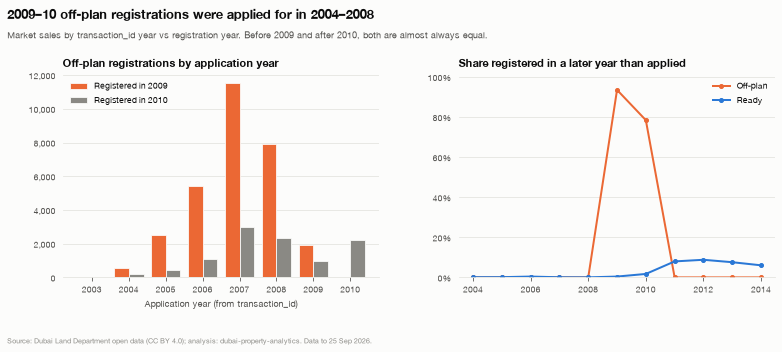

In [7]:
fig, (a1, a2) = P.figure(1, 2, size=(11, 4.8))
fig.subplots_adjust(top=0.80, bottom=0.2, wspace=0.25)
off = lag[lag["is_offplan"] & lag["year"].isin([2009, 2010]) & lag["id_year"].between(2003, 2010)]
piv = off.pivot_table(
    index="id_year", columns="year", values="market_sales", aggfunc="sum", fill_value=0
)
w = 0.4
P.year_bars(
    a1,
    piv.index,
    piv[2009],
    SNAP,
    P.SERIES["offplan"],
    "Registered in 2009",
    width=w,
    offset=-w / 2,
)
P.year_bars(
    a1, piv.index, piv[2010], SNAP, P.SERIES["neutral"], "Registered in 2010", width=w, offset=w / 2
)
a1.set_xticks(piv.index)
a1.grid(False, axis="x")
a1.set_xlabel("Application year (from transaction_id)")
a1.set_title("Off-plan registrations by application year")
P.count_axis(a1)
a1.legend(loc="upper left")
for flag, key, lab in [(True, "offplan", "Off-plan"), (False, "ready", "Ready")]:
    s = summary[summary["is_offplan"] == flag]
    a2.plot(s["year"], s["share_id_year_earlier"], color=P.SERIES[key], marker="o", ms=4, label=lab)
P.pct_axis(a2)
a2.set_ylim(0, 1.02)
a2.set_title("Share registered in a later year than applied")
a2.set_xticks(range(2004, 2015, 2))
a2.grid(False, axis="x")
a2.legend(loc="upper right")
P.titled(
    fig,
    "2009–10 off-plan registrations were applied for in 2004–2008",
    "Market sales by transaction_id year vs registration year. Before 2009 and after 2010, both are almost always equal.",
)
P.add_source(fig, SNAP, partial=False)
P.save(fig, "q1_2009_registration_lag")
plt.show()

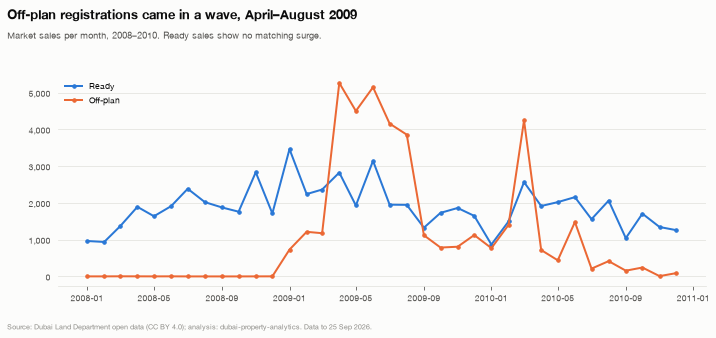

In [8]:
m = monthly[(monthly["month"] >= "2008-01-01") & (monthly["month"] <= "2010-12-31")]
fig, ax = P.figure(size=(10, 4.6))
ax.plot(m["month"], m["ready_sales"], color=P.SERIES["ready"], marker="o", ms=3.5, label="Ready")
ax.plot(
    m["month"], m["offplan_sales"], color=P.SERIES["offplan"], marker="o", ms=3.5, label="Off-plan"
)
P.count_axis(ax)
ax.legend(loc="upper left")
P.titled(
    fig,
    "Off-plan registrations came in a wave, April–August 2009",
    "Market sales per month, 2008–2010. Ready sales show no matching surge.",
)
P.add_source(fig, SNAP, partial=False)
P.save(fig, "q1_2009_monthly_registrations")
plt.show()

In [9]:
print("Off-plan market sales registered in 2009, by the project's first year in the register:")
display(mc.offplan_by_project_first_year(2009))
print("Median AED per sq m, clean sales of residential apartments:")
display(
    mc.ppsqm_offplan_vs_ready(2007, 2011).pivot(
        index="year", columns="is_offplan", values=["clean_sales", "median_ppsqm_aed"]
    )
)

Off-plan market sales registered in 2009, by the project's first year in the register:


,project_first_year,offplan_sales,projects
0,"2,003.000",391,2
1,"2,004.000",2892,8
2,"2,005.000",559,5
3,"2,006.000",474,5
4,"2,007.000",2797,21
5,"2,008.000",13478,182
6,"2,009.000",9194,89
7,NaN,113,1


Median AED per sq m, clean sales of residential apartments:


clean_sales            median_ppsqm_aed           
is_offplan       False      True             False      True 
year                                                         
2007         2,160.000      2.000        5,795.810 19,104.185
2008        10,585.000     11.000        6,673.820  9,884.950
2009        19,974.000 22,328.000        7,252.750 10,193.850
2010        14,316.000  8,079.000        8,970.210 10,861.490
2011        14,923.000  1,849.000        9,034.650  9,522.860

## Findings

1. **Volumes have hit records every year since 2021.** Market sales went from 32,138 (AED 65.5bn) in 2020 to 211,007 (AED 668.3bn) in 2025: 6.6× the count and 10.2× the value. 2026 to 25 Sep: 118,698 sales, AED 364.8bn.
2. **The 2014–19 correction halved activity.** Sales went from 58,159 (AED 135.8bn) in 2013 to 29,712 (AED 66.1bn) in 2018, −49% by count and −51% by value. The 2020 COVID low was 32,138.
3. **The 2009 "spike" is a registration backlog, not demand.** Of 56,340 market sales in 2009, 29,898 (53%) are `Sell - Pre registration`, against 13 in 2008. 93.5% of those off-plan lines carry a `transaction_id` year before 2009 (median lag 2 years, with 11,550 from 2007 alone), and they arrived in an April–August wave (5,267 in April 2009). Ready sales rose only 24% (21,311 → 26,442) while ready value fell 53% (AED 103.2bn → 48.9bn). Off-plan apartments registered in 2009 have a median of AED 10,194 per sq m against 7,253 for 2009 ready sales, consistent with contracts priced near the 2007–08 peak.
4. **2004–2008 volumes understate the market.** The register holds almost no off-plan sales before 2009 (0–13 a year). About 36,000 off-plan sales registered in 2009–10 carry 2004–2008 application years. Pre-2009 counts are ready-only and not comparable with later years, so trend and rate analysis here starts in 2010.

**External source, and what it does and doesn't confirm.** [Dubai Law No. 13 of 2008](https://dlp.dubai.gov.ae/Legislation%20Reference/2008/Law%20No.%20%2813%29%20of%202008.html) (issued 14 August 2008, in force on publication) created the Interim Property Register for off-plan units. Article 3 makes an unregistered off-plan disposition void, and Article 3(2) requires developers to register off-plan sales made *before* the law within 60 days of it coming into force. That fits a one-off wave of back-dated off-plan registrations. What the law does **not** explain is the timing: the wave peaks in April–August 2009, well after a 60-day window from late 2008. Whether that reflects late compliance, an extension, or how DLD migrated the register into this open dataset needs confirmation from DLD.